In [12]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats

TASK_ROOT = Path.cwd().parent
INPUT = TASK_ROOT / "input"
OUTPUT = TASK_ROOT / "output"
FIGURES = OUTPUT / "figures"
RESULTS = OUTPUT / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

EPS = 0.49
Y = 20
PAPER_BG = "#f3f0e9"
INK = "#263238"
EMP_COLOR = "#303030"
MODEL_ORDER = ["arw4", "unfitted_grw", "grw_y", "ar1_y", "ar1_s", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
MODEL_NAMES = {"arw4": "ARW4", "unfitted_grw": "Unfitted-GRW", "grw_y": "GRW-Y", "ar1_y": "AR(1)-GRW-Y", "ar1_s": "AR(1)-GRW-S", "hurdle_ar1_s": "Hurdle-AR(1)-GRW-S", "hurdle_ar1_s_p": "Hurdle-AR(1)-GRW-S-P", "hurdle_ar3_s_p": "Hurdle-AR(3)-GRW-S-P"}
MODEL_COLORS = {"arw4": "#0072B2", "unfitted_grw": "#D55E00", "grw_y": "#E69F00", "ar1_y": "#009E73", "ar1_s": "#56B4E9", "hurdle_ar1_s": "#CC79A7", "hurdle_ar1_s_p": "#6A3D9A", "hurdle_ar3_s_p": "#000000"}
STAGE_ORDER = ["0", "1-4", "5-7", "8-20"]
STAGE_SPANS = [("0", 0, 0), ("1-4", 1, 4), ("5-7", 5, 7), ("8-20", 8, 19)]
STAGE_BOUNDS = [0.5, 4.5, 7.5]


def resolve_root(name, marker):
    for candidate in [INPUT / name, INPUT]:
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(f"no {marker} in {INPUT}")

def style_axis(ax, stages=False):
    ax.set_facecolor(PAPER_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    if stages:
        for boundary in STAGE_BOUNDS:
            ax.axvline(boundary, color="#9aa0a4", lw=0.8, ls=":", zorder=0)


def savefig(fig, filename):
    fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

mpl.rcParams.update({"figure.facecolor": PAPER_BG, "axes.facecolor": PAPER_BG, "savefig.facecolor": PAPER_BG, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 8})
sns.set_theme(style="white", rc={"axes.facecolor": PAPER_BG, "figure.facecolor": PAPER_BG})
PREPARE = resolve_root("prepare", "df_traj_all.csv")
SIMULATE = resolve_root("simulate", "simulation-registry.csv")

In [13]:
emp = pd.read_csv(PREPARE / "df_traj_all.csv")
emp["CareerAge"] = emp["CareerAgeZero"].astype(int)
emp = emp.sort_values(["dblp_id", "CareerAge"]).copy()
grouped = emp.groupby("dblp_id", sort=False)
emp["pubs_adj_next_model"] = grouped["pubs_adj"].shift(-1)
emp["CareerAge_next_model"] = grouped["CareerAge"].shift(-1)
emp["log_pubs_adj"] = np.log(emp["pubs_adj"] + EPS)
emp["log_pubs_next"] = grouped["log_pubs_adj"].shift(-1)
emp["q_adj_delta"] = emp["pubs_adj_next_model"] - emp["pubs_adj"]
emp["log_delta"] = emp["log_pubs_next"] - emp["log_pubs_adj"]
emp["state"] = emp["pubs_adj"].gt(0).astype(int)
emp["next_state"] = emp["pubs_adj_next_model"].gt(0).astype(int)
is_next_year = emp["CareerAge_next_model"].eq(emp["CareerAge"] + 1)
emp_fit = emp.loc[is_next_year & emp["CareerAge"].between(0, Y - 1)].copy()

full_group = emp.groupby("dblp_id")["CareerAge"]
full_mask = full_group.transform("size").eq(Y + 1) & full_group.transform("min").eq(0) & full_group.transform("max").eq(Y)
emp_full_frame = emp.loc[full_mask].copy()
emp_panel_df = emp_full_frame.pivot(index="CareerAge", columns="dblp_id", values="pubs_adj").reindex(np.arange(Y + 1))
emp_panel = emp_panel_df.to_numpy(dtype=float)

simulation_registry = pd.read_csv(SIMULATE / "simulation-registry.csv")
available_models = [tag for tag in MODEL_ORDER if (SIMULATE / tag / "trajectories.npy").is_file()]
trajs = {tag: np.load(SIMULATE / tag / "trajectories.npy", mmap_mode="r", allow_pickle=False) for tag in available_models}
print(f"Empirical rows: {len(emp):,}; full-cohort scholars: {emp_panel.shape[1]:,}")
print(f"Loaded models: {[MODEL_NAMES[tag] for tag in available_models]}")

Empirical rows: 29,119; full-cohort scholars: 510
Loaded models: ['ARW4', 'Unfitted-GRW', 'GRW-Y', 'AR(1)-GRW-Y', 'AR(1)-GRW-S', 'Hurdle-AR(1)-GRW-S', 'Hurdle-AR(1)-GRW-S-P', 'Hurdle-AR(3)-GRW-S-P']


In [14]:
MAX_DIAGNOSTIC_N = 10000
rng = np.random.default_rng(20260626)
sim_samples = {}
for tag, values in trajs.items():
    n = min(values.shape[1], MAX_DIAGNOSTIC_N)
    ix = rng.choice(values.shape[1], size=n, replace=False) if n < values.shape[1] else np.arange(n)
    sim_samples[tag] = np.asarray(values[:, ix], dtype=float)


def ecdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    values = values[np.isfinite(values)]
    return values, np.arange(1, len(values) + 1) / len(values)


def survival(values):
    values = np.asarray(values, dtype=int)
    support = np.arange(values.min(), values.max() + 1)
    return support, np.array([(values >= k).mean() for k in support])

In [ ]:
q0_emp = emp.loc[emp["CareerAge"].eq(0), "pubs_adj"].dropna().to_numpy(dtype=float)
q0_scale = q0_emp.mean()
xmax = max(np.quantile(q0_emp, 0.995), 1)
xgrid = np.linspace(0, xmax, 400)
fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.8))
fig.patch.set_facecolor(PAPER_BG)
for ax in axes: style_axis(ax)
axes[0].hist(q0_emp, bins=45, range=(0, xmax), density=True, color="#d95f8d", alpha=0.72, edgecolor=PAPER_BG, label="Empirical")
axes[0].plot(xgrid, stats.expon.pdf(xgrid, scale=q0_scale), color=INK, lw=2.3, ls="--", label=f"Exponential, scale={q0_scale:.2f}")
axes[0].set_yscale("log")
axes[0].set(xlabel=r"First-year productivity, $q_0$", ylabel="Density", title="Empirical first-year productivity")
axes[0].legend(frameon=False)

q0_rows = [{"source": "Empirical", "model_tag": "empirical", "n": len(q0_emp), "mean": q0_emp.mean(), "variance": q0_emp.var(), "zero_fraction": np.mean(q0_emp == 0), "exponential_scale": q0_scale}]
for tag in available_models:
    vals = sim_samples[tag][0]
    hist, edges = np.histogram(vals, bins=70, range=(0, xmax), density=True)
    axes[1].plot((edges[:-1] + edges[1:]) / 2, hist, color=MODEL_COLORS[tag], lw=1.7, label=MODEL_NAMES[tag])
    q0_rows.append({"source": MODEL_NAMES[tag], "model_tag": tag, "n": len(vals), "mean": vals.mean(), "variance": vals.var(), "zero_fraction": np.mean(vals == 0), "exponential_scale": vals.mean()})
axes[1].hist(q0_emp, bins=70, range=(0, xmax), density=True, histtype="step", color=EMP_COLOR, lw=2.4, label="Empirical")
axes[1].set_yscale("log")
axes[1].set(xlabel=r"First-year productivity, $q_0$", ylabel="Density", title="First-year distributions, all models")
axes[1].legend(frameon=False, ncol=2)

mean_rows = []
emp_by_year = emp.groupby("CareerAge")["pubs_adj"]
emp_mean, emp_se = emp_by_year.mean().reindex(np.arange(Y + 1)), emp_by_year.sem().reindex(np.arange(Y + 1))
axes[2].plot(np.arange(Y + 1), emp_mean, color=EMP_COLOR, lw=3, ls=":", label="Empirical", zorder=20)
axes[2].fill_between(np.arange(Y + 1), emp_mean - 1.96 * emp_se, emp_mean + 1.96 * emp_se, color=EMP_COLOR, alpha=0.13)
mean_rows += [{"source": "Empirical", "model_tag": "empirical", "year": year, "mean": emp_mean.loc[year], "se": emp_se.loc[year]} for year in range(Y + 1)]
for tag in available_models:
    vals = sim_samples[tag]
    mean, se = vals.mean(axis=1), vals.std(axis=1, ddof=1) / np.sqrt(vals.shape[1])
    axes[2].plot(np.arange(Y + 1), mean, color=MODEL_COLORS[tag], lw=1.8, label=MODEL_NAMES[tag])
    mean_rows += [{"source": MODEL_NAMES[tag], "model_tag": tag, "year": year, "mean": mean[year], "se": se[year]} for year in range(Y + 1)]
for boundary in STAGE_BOUNDS: axes[2].axvline(boundary, color="#9aa0a4", lw=0.8, ls=":")
axes[2].set(xlabel="Career year", ylabel="Mean annual productivity", title="Canonical mean trajectory")
axes[2].legend(frameon=False, ncol=2)
fig.tight_layout()
savefig(fig, "zhang_initialization_and_canonical_trajectory.png")
plt.show()
pd.DataFrame(q0_rows).to_csv(RESULTS / "zhang-initial-productivity-summary.csv", index=False)
pd.DataFrame(mean_rows).to_csv(RESULTS / "zhang-canonical-trajectory-summary.csv", index=False)

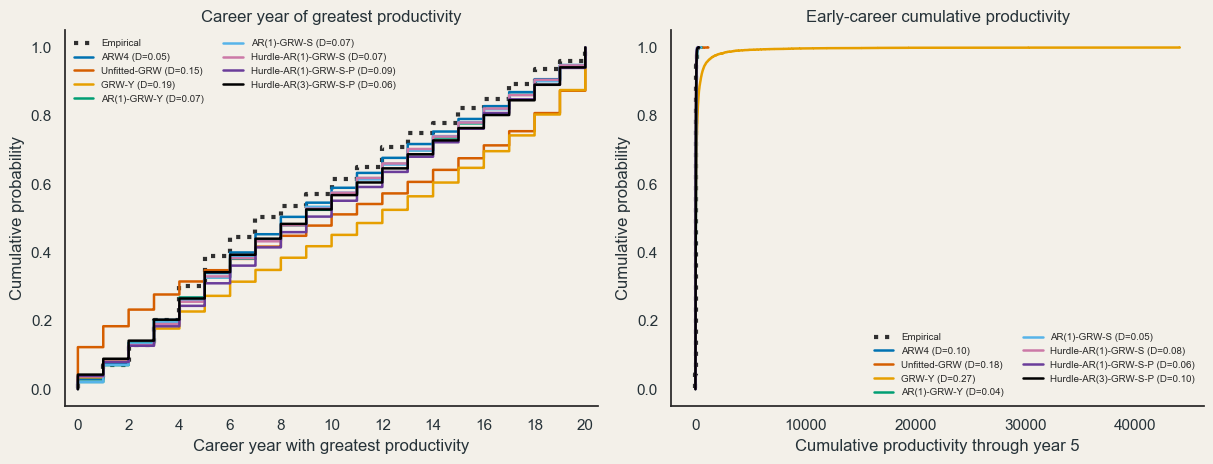

In [ ]:
emp_year_max, emp_cum5 = np.argmax(emp_panel, axis=0), emp_panel[:6].sum(axis=0)
rows = []
fig, axes = plt.subplots(1, 2, figsize=(12.3, 4.8))
fig.patch.set_facecolor(PAPER_BG)
for ax in axes: style_axis(ax)
x, y = ecdf(emp_year_max); axes[0].step(x, y, where="post", color=EMP_COLOR, lw=3, ls=":", label="Empirical")
x, y = ecdf(emp_cum5); axes[1].step(x, y, where="post", color=EMP_COLOR, lw=3, ls=":", label="Empirical")
for tag in available_models:
    values = sim_samples[tag]
    year_max, cum5 = np.argmax(values, axis=0), values[:6].sum(axis=0)
    ks_max, ks_cum = stats.ks_2samp(emp_year_max, year_max), stats.ks_2samp(emp_cum5, cum5)
    x, y = ecdf(year_max); axes[0].step(x, y, where="post", color=MODEL_COLORS[tag], lw=1.8, label=f"{MODEL_NAMES[tag]} (D={ks_max.statistic:.2f})")
    x, y = ecdf(cum5); axes[1].step(x, y, where="post", color=MODEL_COLORS[tag], lw=1.8, label=f"{MODEL_NAMES[tag]} (D={ks_cum.statistic:.2f})")
    rows += [{"model": MODEL_NAMES[tag], "model_tag": tag, "diagnostic": "year_of_max", "ks_D": ks_max.statistic, "ks_p": ks_max.pvalue}, {"model": MODEL_NAMES[tag], "model_tag": tag, "diagnostic": "cumulative_by_year_5", "ks_D": ks_cum.statistic, "ks_p": ks_cum.pvalue}]
axes[0].set(xlim=(-0.5, Y + 0.5), xlabel="Career year with greatest productivity", ylabel="Cumulative probability", title="Career year of greatest productivity")
axes[0].set_xticks(np.arange(0, Y + 1, 2))
axes[1].set(xlabel="Cumulative productivity through year 5", ylabel="Cumulative probability", title="Early-career cumulative productivity")
for ax in axes: ax.legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
savefig(fig, "zhang_year_max_and_cumulative_year5.png")
plt.show()
pd.DataFrame(rows).to_csv(RESULTS / "zhang-year-max-and-cumulative-year5.csv", index=False)

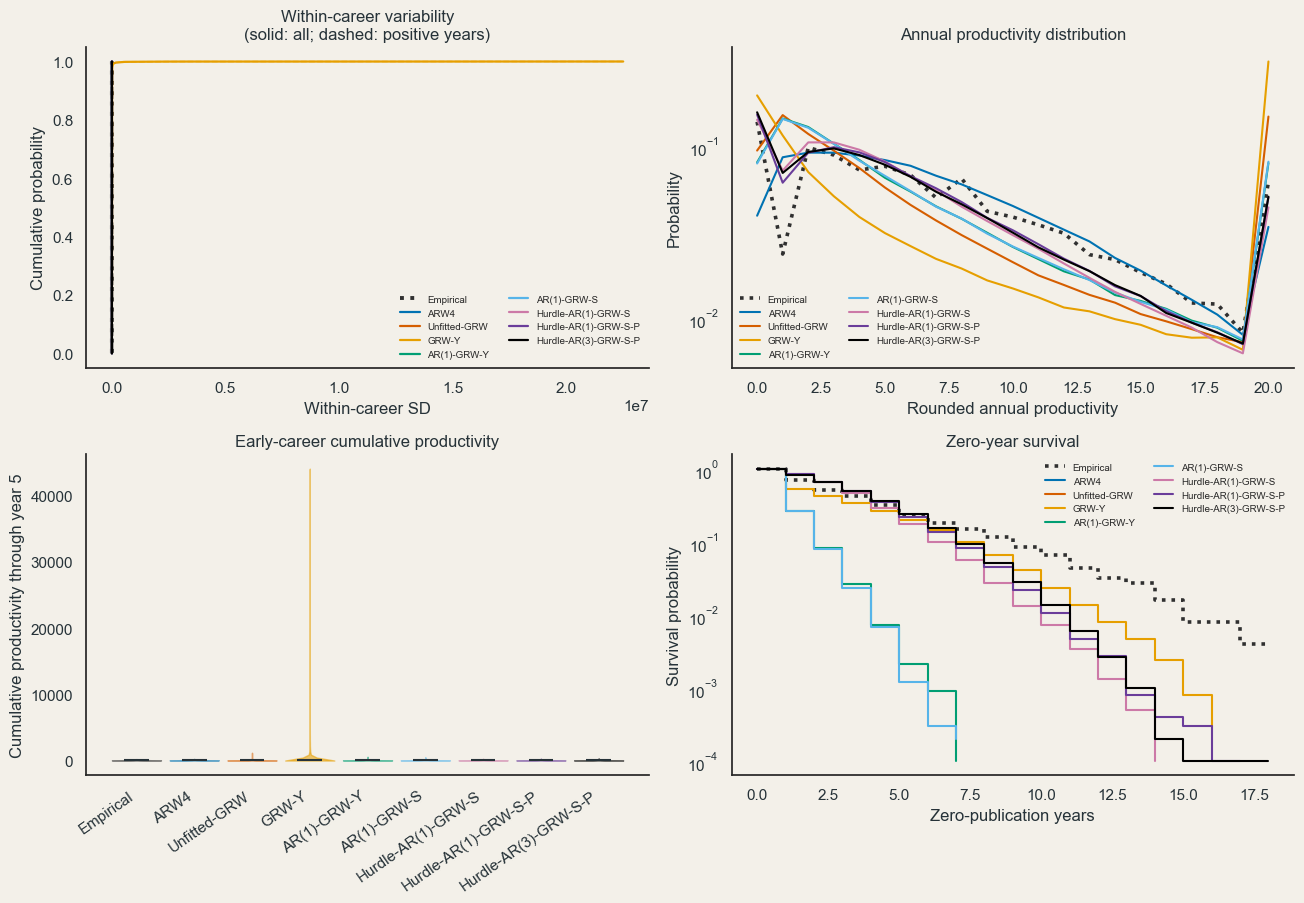

In [ ]:
sources = {"empirical": emp_panel, **sim_samples}
career_sd, career_sd_pos, zero_counts, annual, cum5 = {}, {}, {}, {}, {}
for tag, values in sources.items():
    values = np.asarray(values, dtype=float)
    career_sd[tag] = values.std(axis=0)
    career_sd_pos[tag] = np.array([row[row > 0].std() if np.sum(row > 0) > 1 else np.nan for row in values.T])
    zero_counts[tag] = np.sum(values == 0, axis=0)
    annual[tag] = values.ravel()
    cum5[tag] = values[:6].sum(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(13.2, 9.2))
fig.patch.set_facecolor(PAPER_BG)
for ax in axes.flat: style_axis(ax)
for tag in sources:
    name, color = ("Empirical", EMP_COLOR) if tag == "empirical" else (MODEL_NAMES[tag], MODEL_COLORS[tag])
    lw = 2.8 if tag == "empirical" else 1.6
    x, y = ecdf(career_sd[tag]); axes[0, 0].plot(x, y, color=color, lw=lw, ls=":" if tag == "empirical" else "-", label=name)
    x, y = ecdf(career_sd_pos[tag][np.isfinite(career_sd_pos[tag])]); axes[0, 0].plot(x, y, color=color, lw=max(lw - 0.5, 1), ls="--", alpha=0.65)
axes[0, 0].set(xlabel="Within-career SD", ylabel="Cumulative probability", title="Within-career variability\n(solid: all; dashed: positive years)")

support = np.arange(21)
for tag in sources:
    name, color = ("Empirical", EMP_COLOR) if tag == "empirical" else (MODEL_NAMES[tag], MODEL_COLORS[tag])
    rounded = np.rint(np.clip(annual[tag], 0, 20)).astype(int)
    pmf = np.array([(rounded == k).mean() for k in support])
    axes[0, 1].plot(support, pmf, color=color, lw=2.6 if tag == "empirical" else 1.5, ls=":" if tag == "empirical" else "-", label=name)
axes[0, 1].set_yscale("log")
axes[0, 1].set(xlabel="Rounded annual productivity", ylabel="Probability", title="Annual productivity distribution")

labels = ["Empirical"] + [MODEL_NAMES[tag] for tag in available_models]
data = [cum5["empirical"]] + [cum5[tag] for tag in available_models]
parts = axes[1, 0].violinplot(data, positions=np.arange(len(data)), showmedians=True, showextrema=False, widths=0.85)
for body, color in zip(parts["bodies"], [EMP_COLOR] + [MODEL_COLORS[tag] for tag in available_models]):
    body.set_facecolor(color); body.set_edgecolor(color); body.set_alpha(0.55)
parts["cmedians"].set_color(INK)
axes[1, 0].set_xticks(np.arange(len(labels)), labels, rotation=35, ha="right")
axes[1, 0].set(ylabel="Cumulative productivity through year 5", title="Early-career cumulative productivity")

for tag in sources:
    name, color = ("Empirical", EMP_COLOR) if tag == "empirical" else (MODEL_NAMES[tag], MODEL_COLORS[tag])
    x, y = survival(zero_counts[tag]); mask = y > 0
    axes[1, 1].step(x[mask], y[mask], where="post", color=color, lw=2.6 if tag == "empirical" else 1.5, ls=":" if tag == "empirical" else "-", label=name)
axes[1, 1].set_yscale("log")
axes[1, 1].set(xlabel="Zero-publication years", ylabel="Survival probability", title="Zero-year survival")
axes[0, 0].legend(frameon=False, fontsize=7, ncol=2)
axes[0, 1].legend(frameon=False, fontsize=7, ncol=2)
axes[1, 1].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
savefig(fig, "zhang_figure4_all_models.png")
plt.show()

rows = []
for tag in available_models:
    sd = stats.ks_2samp(career_sd["empirical"], career_sd[tag])
    zero = stats.ks_2samp(zero_counts["empirical"], zero_counts[tag])
    early = stats.ttest_ind(cum5["empirical"], cum5[tag], equal_var=False)
    rows.append({"model": MODEL_NAMES[tag], "model_tag": tag, "career_sd_ks_D": sd.statistic, "career_sd_ks_p": sd.pvalue, "zero_count_ks_D": zero.statistic, "zero_count_ks_p": zero.pvalue, "cum5_t": early.statistic, "cum5_p": early.pvalue})
pd.DataFrame(rows).to_csv(RESULTS / "zhang-figure4-summary.csv", index=False)

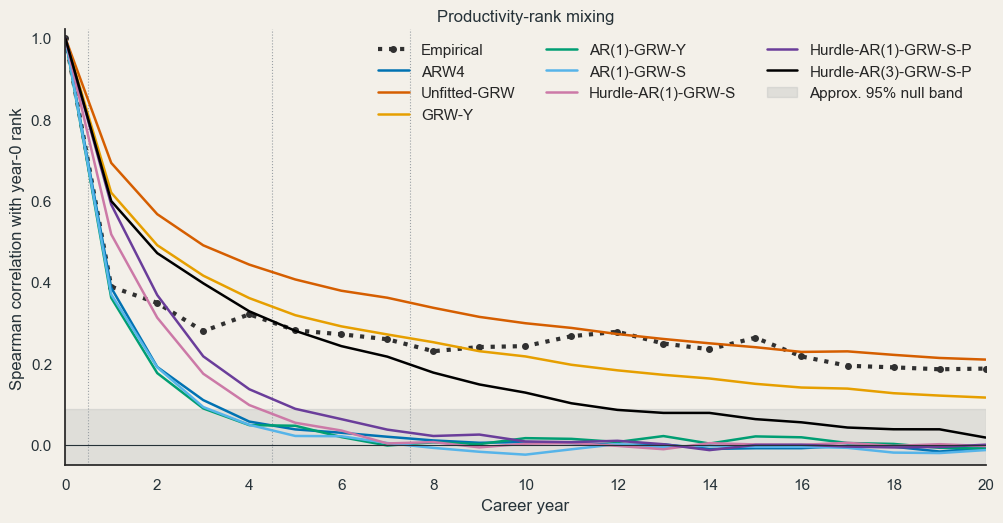

In [ ]:
def rank_curve(values):
    values = np.asarray(values, dtype=float)
    return np.array([stats.spearmanr(values[0], values[year]).statistic for year in range(Y + 1)])

rows = []
fig, ax = plt.subplots(figsize=(10.2, 5.4))
fig.patch.set_facecolor(PAPER_BG)
style_axis(ax, stages=True)
curve = rank_curve(emp_panel)
ax.plot(np.arange(Y + 1), curve, color=EMP_COLOR, lw=3, ls=":", marker="o", ms=4, label="Empirical")
rows += [{"source": "Empirical", "model_tag": "empirical", "year": year, "spearman": curve[year]} for year in range(Y + 1)]
for tag in available_models:
    curve = rank_curve(sim_samples[tag])
    ax.plot(np.arange(Y + 1), curve, color=MODEL_COLORS[tag], lw=1.8, label=MODEL_NAMES[tag])
    rows += [{"source": MODEL_NAMES[tag], "model_tag": tag, "year": year, "spearman": curve[year]} for year in range(Y + 1)]
band = 1.96 / np.sqrt(max(emp_panel.shape[1] - 1, 1))
ax.axhspan(-band, band, color="#9aa0a4", alpha=0.22, label="Approx. 95% null band")
ax.axhline(0, color=INK, lw=0.8)
ax.set(xlim=(0, Y), ylim=(-0.05, 1.02), xlabel="Career year", ylabel="Spearman correlation with year-0 rank", title="Productivity-rank mixing")
ax.set_xticks(np.arange(0, Y + 1, 2))
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
savefig(fig, "zhang_rank_mixing.png")
plt.show()
pd.DataFrame(rows).to_csv(RESULTS / "zhang-rank-mixing.csv", index=False)

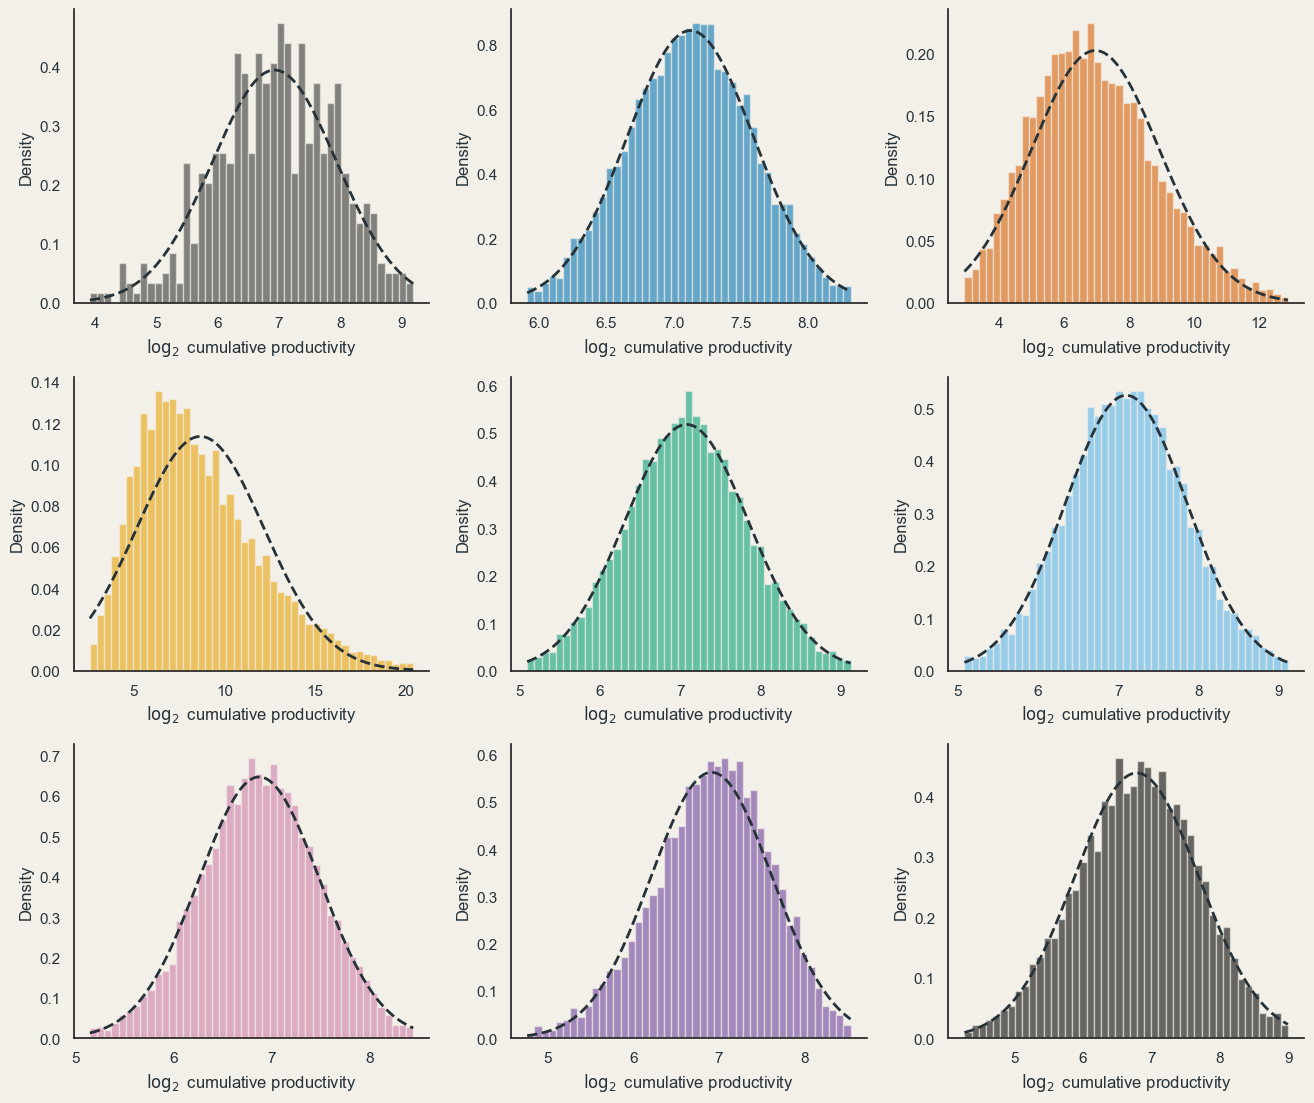

In [ ]:
cum_sources = {"empirical": emp_panel.sum(axis=0), **{tag: sim_samples[tag].sum(axis=0) for tag in available_models}}
fig, axes = plt.subplots(3, 3, figsize=(13.3, 11.2))
fig.patch.set_facecolor(PAPER_BG)
rows = []
for ax, tag in zip(axes.flat, cum_sources):
    style_axis(ax)
    raw = np.asarray(cum_sources[tag], dtype=float)
    logged = np.log2(raw[np.isfinite(raw) & (raw > 0)])
    mu, sigma = stats.norm.fit(logged)
    ks = stats.kstest(logged, "norm", args=(mu, sigma))
    color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
    name = "Empirical" if tag == "empirical" else MODEL_NAMES[tag]
    lo, hi = np.quantile(logged, [0.005, 0.995])
    grid = np.linspace(lo, hi, 400)
    ax.hist(logged, bins=45, range=(lo, hi), density=True, color=color, alpha=0.58, edgecolor=PAPER_BG)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), color=INK, lw=2, ls="--")
    ax.set(xlabel=r"$\log_2$ cumulative productivity", ylabel="Density")
    rows.append({"source": name, "model_tag": tag, "n": len(logged), "log2_mean": mu, "log2_sd": sigma, "ks_D": ks.statistic, "ks_p": ks.pvalue})
for ax in axes.flat[len(cum_sources):]: ax.axis("off")
fig.tight_layout()
savefig(fig, "zhang_cumulative_lognormal_histograms.png")
plt.show()
pd.DataFrame(rows).to_csv(RESULTS / "zhang-cumulative-lognormal-summary.csv", index=False)

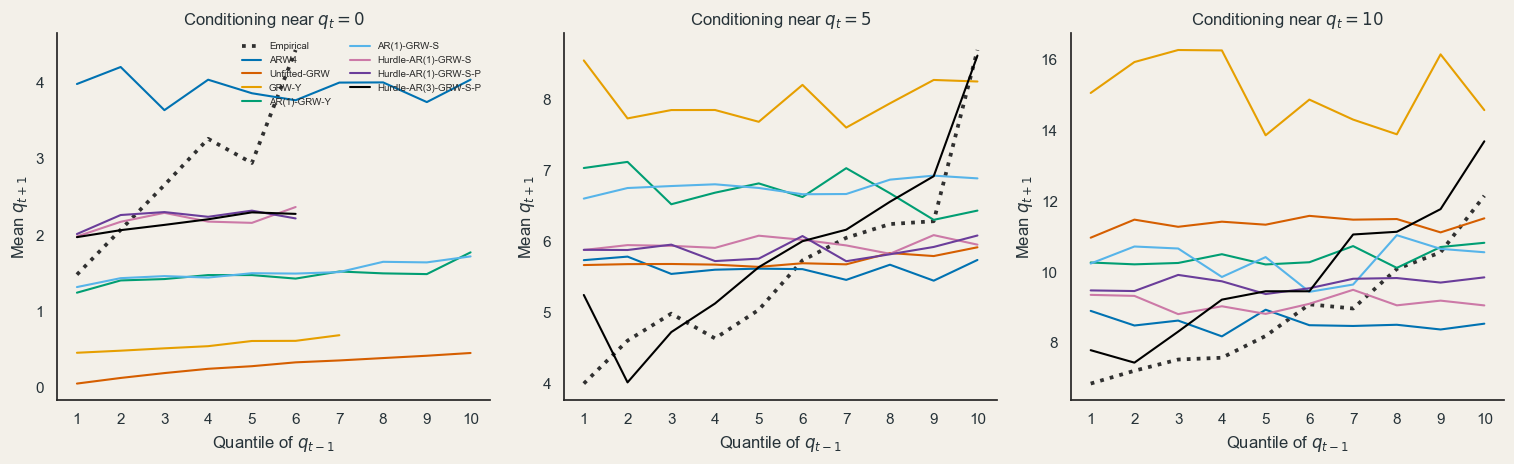

In [ ]:
triplet_emp = emp.copy()
triplet_emp["q_prev"] = triplet_emp.groupby("dblp_id")["pubs_adj"].shift(1)
triplet_emp["age_prev"] = triplet_emp.groupby("dblp_id")["CareerAge"].shift(1)
triplet_emp = triplet_emp.loc[triplet_emp["age_prev"].eq(triplet_emp["CareerAge"] - 1) & triplet_emp["CareerAge_next_model"].eq(triplet_emp["CareerAge"] + 1), ["q_prev", "pubs_adj", "pubs_adj_next_model"]]
triplet_emp.columns = ["q_prev", "q_now", "q_next"]


def sim_triplets(values):
    values = np.asarray(values, dtype=float)
    return pd.DataFrame({"q_prev": values[:-2].ravel(), "q_now": values[1:-1].ravel(), "q_next": values[2:].ravel()})


def conditional(frame, target):
    selected = frame.loc[np.abs(frame["q_now"] - target) <= 0.5].copy()
    if len(selected) < 400:
        selected = frame.assign(distance=np.abs(frame["q_now"] - target)).nsmallest(min(2500, len(frame)), "distance").drop(columns="distance")
    q = min(10, selected["q_prev"].nunique())
    if q < 2: return pd.DataFrame()
    selected["previous_quantile"] = pd.qcut(selected["q_prev"], q=q, labels=False, duplicates="drop") + 1
    out = selected.groupby("previous_quantile", observed=True).agg(n=("q_next", "size"), previous_mean=("q_prev", "mean"), next_mean=("q_next", "mean"), next_median=("q_next", "median")).reset_index()
    out["target_q_now"] = target
    return out

triplets = {"empirical": triplet_emp, **{tag: sim_triplets(sim_samples[tag]) for tag in available_models}}
frames = []
fig, axes = plt.subplots(1, 3, figsize=(15.3, 4.8))
fig.patch.set_facecolor(PAPER_BG)
for ax, target in zip(axes, [0, 5, 10]):
    style_axis(ax)
    for tag, frame in triplets.items():
        summary = conditional(frame, target)
        if summary.empty: continue
        summary["source"] = "Empirical" if tag == "empirical" else MODEL_NAMES[tag]
        summary["model_tag"] = tag
        frames.append(summary)
        color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
        ax.plot(summary["previous_quantile"], summary["next_mean"], color=color, lw=2.7 if tag == "empirical" else 1.5, ls=":" if tag == "empirical" else "-", label=summary["source"].iloc[0])
    ax.set(xlabel=r"Quantile of $q_{t-1}$", ylabel=r"Mean $q_{t+1}$", title=fr"Conditioning near $q_t={target}$")
    ax.set_xticks(np.arange(1, 11))
axes[0].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout()
savefig(fig, "zhang_conditional_memory_s3.png")
plt.show()
pd.concat(frames, ignore_index=True).to_csv(RESULTS / "zhang-conditional-memory-s3.csv", index=False)

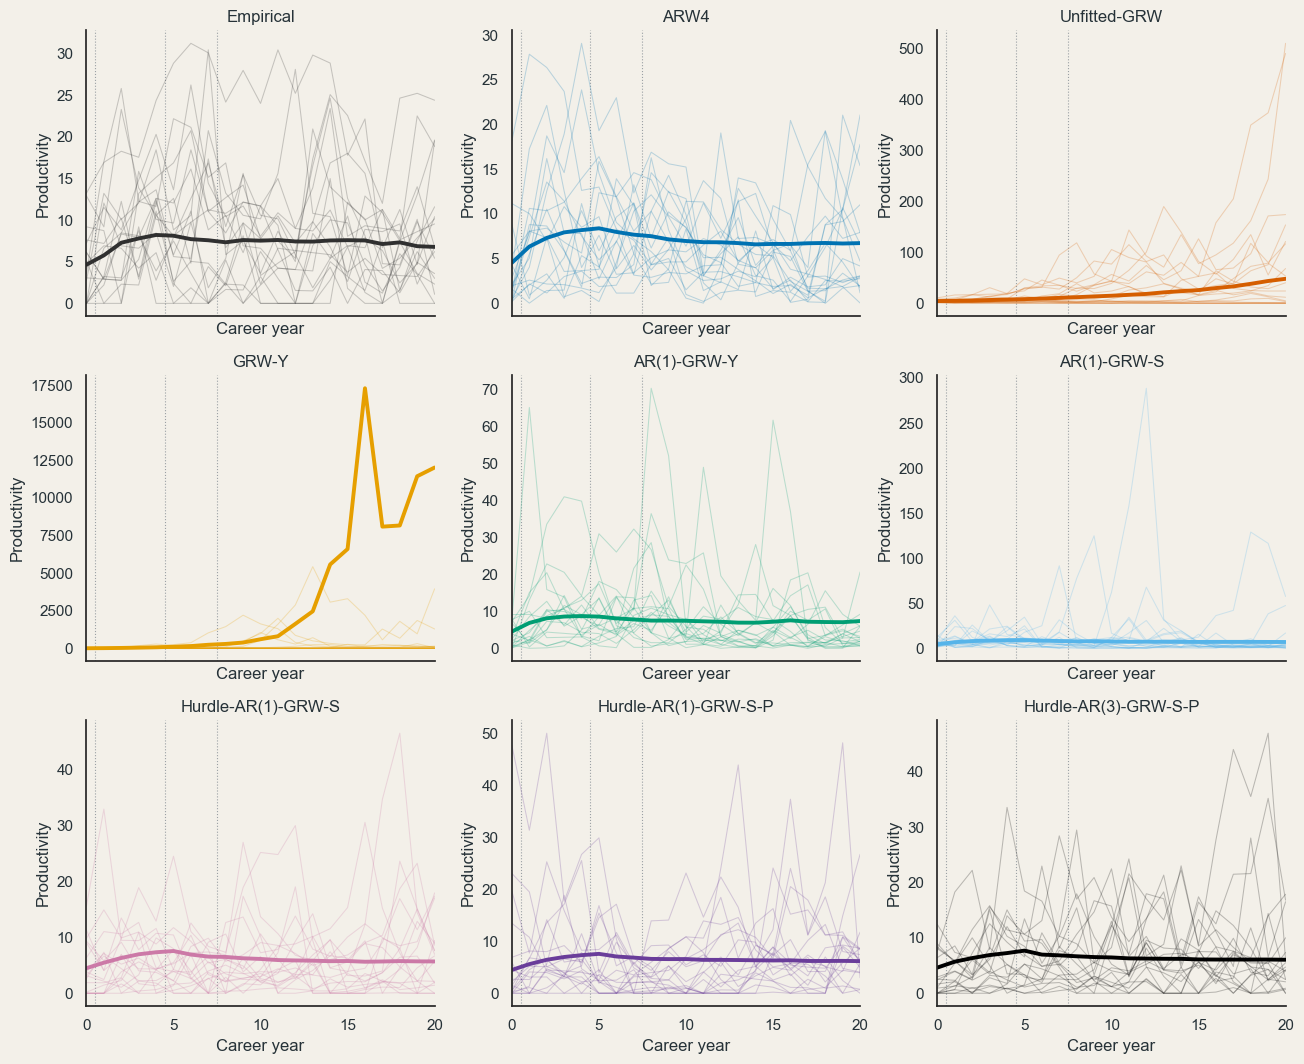

In [ ]:
sources = {"empirical": emp_panel, **sim_samples}
fig, axes = plt.subplots(3, 3, figsize=(13.2, 10.8), sharex=True)
fig.patch.set_facecolor(PAPER_BG)
rng_plot = np.random.default_rng(20260627)
rows = []
for ax, (tag, values) in zip(axes.flat, sources.items()):
    style_axis(ax, stages=True)
    values = np.asarray(values, dtype=float)
    ix = rng_plot.choice(values.shape[1], size=min(18, values.shape[1]), replace=False)
    color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
    name = "Empirical" if tag == "empirical" else MODEL_NAMES[tag]
    for scholar in ix:
        ax.plot(np.arange(Y + 1), values[:, scholar], color=color, lw=0.75, alpha=0.24)
        rows += [{"source": name, "model_tag": tag, "trajectory_index": int(scholar), "year": year, "productivity": values[year, scholar]} for year in range(Y + 1)]
    ax.plot(np.arange(Y + 1), values.mean(axis=1), color=color, lw=2.8)
    ax.set(xlim=(0, Y), xlabel="Career year", ylabel="Productivity", title=name)
for ax in axes.flat[len(sources):]: ax.axis("off")
fig.tight_layout()
savefig(fig, "zhang_representative_trajectories.png")
plt.show()
pd.DataFrame(rows).to_csv(RESULTS / "zhang-representative-trajectory-sample.csv", index=False)